# Support Ticket Exploratory Data Analysis

**Project:** AI Customer Support & Resolution Assistant  
**Company:** ServeFlow (fictional)  
**Role:** Business Analyst & Product Manager  
**Dataset:** Synthetic support-ticket dataset  
**Period:** January–June 2026

## Objective

This notebook establishes the baseline for ServeFlow's support operation and investigates the business questions defined in `docs/04_data_requirements.md`.

The analysis is intentionally evidence-first: product and AI priorities will be informed by observed patterns rather than assumed upfront.

> **Data note:** The dataset is synthetic and is used only for portfolio/case-study purposes.


## 1. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = "../../data/raw/support_tickets.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["created_at"])

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()


Rows: 5,000
Columns: 21


,ticket_id,customer_id,created_at,channel,customer_tier,subject,description,category,sub_category,product_area,priority,agent_id,first_response_time_mins,resolution_time_hours,status,escalated,reopened,repeat_contact,sla_breached,csat_score,resolution_type
0,TKT_004691,CUST_0748,2026-01-01 00:08:00,Email,Standard,Customer wants to update profile information.,Customer wants to update profile information. ...,Account,Login Issue,Identity & Access,Medium,AGT_013,38.87,2.46,Closed,False,False,False,False,5,Knowledge Base
1,TKT_003674,CUST_0493,2026-01-01 00:26:00,Email,Enterprise,Customer needs help configuring the platform.,Customer needs help configuring the platform. ...,Product Usage,How-To Question,Platform Features,High,AGT_020,21.71,9.50,Resolved,False,False,False,False,4,Agent Resolution
2,TKT_002628,CUST_0145,2026-01-01 01:28:00,Email,Professional,Customer reports an application error while us...,Customer reports an application error while us...,Technical,Data Sync,Core Platform,High,AGT_005,41.83,33.79,Resolved,False,False,True,True,3,Technical Fix
3,TKT_002259,CUST_0326,2026-01-01 03:26:00,Live Chat,Professional,Customer says a payment failed and needs help ...,Customer says a payment failed and needs help ...,Billing,Invoice Issue,Payments,Medium,AGT_008,9.97,9.50,Escalated,True,False,False,False,4,Agent Resolution
4,TKT_004111,CUST_0283,2026-01-01 03:42:00,Web Form,Standard,Customer says a payment failed and needs help ...,Customer says a payment failed and needs help ...,Billing,Payment Failure,Payments,Medium,AGT_004,29.30,11.02,Closed,False,False,False,False,4,Customer Follow-up


## 2. Data Quality Checks

We check completeness, uniqueness, valid ranges, and basic data consistency before using the data for business conclusions.

In [2]:
quality_report = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Duplicate ticket IDs",
        "Missing cells",
        "Invalid CSAT scores",
        "Negative first-response times",
        "Negative resolution times",
    ],
    "result": [
        len(df),
        len(df.columns),
        df["ticket_id"].duplicated().sum(),
        df.isna().sum().sum(),
        ((df["csat_score"] < 1) | (df["csat_score"] > 5)).sum(),
        (df["first_response_time_mins"] < 0).sum(),
        (df["resolution_time_hours"] < 0).sum(),
    ]
})

quality_report


,check,result
0,Rows,5000
1,Columns,21
2,Duplicate ticket IDs,0
3,Missing cells,0
4,Invalid CSAT scores,0
5,Negative first-response times,0
6,Negative resolution times,0


In [3]:
print("Date range:", df["created_at"].min().date(), "to", df["created_at"].max().date())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nUnique values:")
for col in ["channel", "customer_tier", "category", "priority", "status", "resolution_type"]:
    print(f"{col}: {df[col].nunique()}")


Date range: 2026-01-01 to 2026-06-30

Missing values:


ticket_id        0
customer_id      0
created_at       0
channel          0
customer_tier    0
subject          0
description      0
category         0
sub_category     0
product_area     0
dtype: int64


Unique values:
channel: 4
customer_tier: 3
category: 8
priority: 4
status: 3
resolution_type: 7


## 3. Baseline KPIs

These are descriptive baseline metrics. They are not targets and should not be presented as production benchmarks.

In [4]:
kpis = pd.Series({
    "Ticket volume": len(df),
    "Average resolution time (hours)": df["resolution_time_hours"].mean(),
    "Median resolution time (hours)": df["resolution_time_hours"].median(),
    "Average first response (minutes)": df["first_response_time_mins"].mean(),
    "Escalation rate": df["escalated"].mean(),
    "SLA breach rate": df["sla_breached"].mean(),
    "Repeat contact rate": df["repeat_contact"].mean(),
    "Reopen rate": df["reopened"].mean(),
    "Average CSAT": df["csat_score"].mean(),
})
kpis


Ticket volume                      5,000.00
Average resolution time (hours)       10.61
Median resolution time (hours)         7.16
Average first response (minutes)      47.69
Escalation rate                        0.15
SLA breach rate                        0.21
Repeat contact rate                    0.08
Reopen rate                            0.06
Average CSAT                           4.04
dtype: float64

## 4. Ticket Volume by Category

**Business question:** Which support categories generate the largest workload?

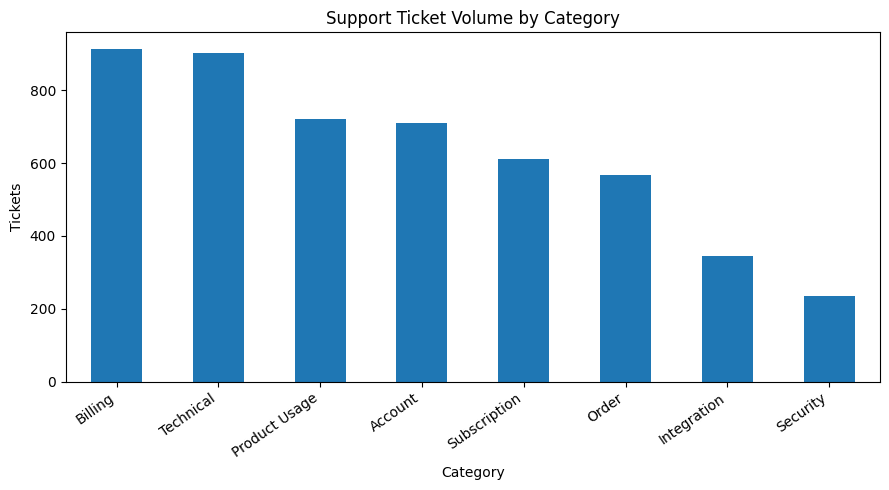

In [5]:
category_volume = df["category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
category_volume.plot(kind="bar")
plt.title("Support Ticket Volume by Category")
plt.xlabel("Category")
plt.ylabel("Tickets")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 5. Operational Performance by Category

We compare workload, resolution time, escalation, SLA breaches, repeat contact, and CSAT together so that volume alone does not determine product priority.

In [6]:
category_analysis = (
    df.groupby("category")
      .agg(
          tickets=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          escalation_rate=("escalated", "mean"),
          sla_breach_rate=("sla_breached", "mean"),
          repeat_contact_rate=("repeat_contact", "mean"),
          avg_csat=("csat_score", "mean"),
      )
      .sort_values("tickets", ascending=False)
)

category_analysis.style.format({
    "avg_resolution_hours": "{:.2f}",
    "escalation_rate": "{:.1%}",
    "sla_breach_rate": "{:.1%}",
    "repeat_contact_rate": "{:.1%}",
    "avg_csat": "{:.2f}",
})


,tickets,avg_resolution_hours,escalation_rate,sla_breach_rate,repeat_contact_rate,avg_csat
category,,,,,,
Billing,913,6.42,6.9%,9.3%,12.5%,4.16
Technical,901,19.74,30.3%,46.9%,13.3%,3.80
Product Usage,721,5.91,7.8%,7.8%,4.3%,4.17
Account,710,4.24,9.0%,6.8%,6.2%,4.19
Subscription,610,7.22,7.0%,9.0%,4.8%,4.15
Order,567,8.68,7.2%,11.8%,3.9%,4.11
Integration,344,21.83,30.2%,57.6%,13.4%,3.65
Security,234,22.63,37.6%,52.1%,5.1%,3.79


## 6. Resolution Time by Category

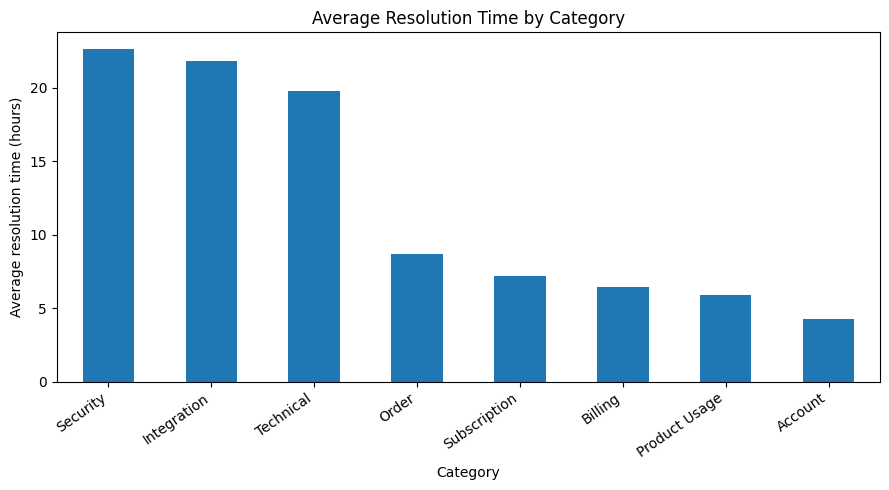

In [7]:
plt.figure(figsize=(9, 5))
(
    df.groupby("category")["resolution_time_hours"]
      .mean()
      .sort_values(ascending=False)
      .plot(kind="bar")
)
plt.title("Average Resolution Time by Category")
plt.xlabel("Category")
plt.ylabel("Average resolution time (hours)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 7. Priority and SLA Performance

In [8]:
priority_analysis = (
    df.groupby("priority")
      .agg(
          tickets=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          sla_breach_rate=("sla_breached", "mean"),
          escalation_rate=("escalated", "mean"),
          avg_csat=("csat_score", "mean"),
      )
      .reindex(["Low", "Medium", "High", "Critical"])
)

priority_analysis.style.format({
    "avg_resolution_hours": "{:.2f}",
    "sla_breach_rate": "{:.1%}",
    "escalation_rate": "{:.1%}",
    "avg_csat": "{:.2f}",
})


,tickets,avg_resolution_hours,sla_breach_rate,escalation_rate,avg_csat
priority,,,,,
Low,931,4.81,3.0%,5.0%,4.20
Medium,1839,7.49,3.1%,8.7%,4.13
High,1593,12.78,27.7%,21.1%,3.95
Critical,637,22.65,82.9%,29.7%,3.75


## 8. Escalation Analysis

**Business question:** Which issue types are associated with escalations?

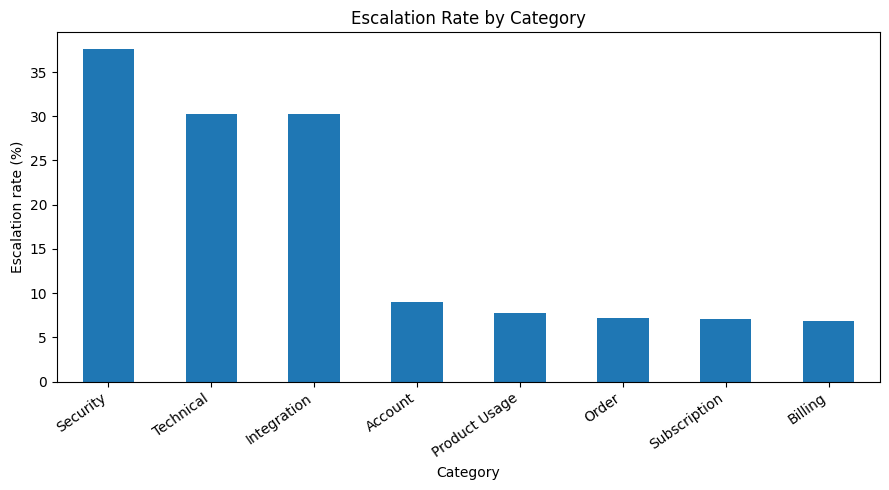

In [9]:
escalation_by_category = (
    df.groupby("category")["escalated"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
(escalation_by_category * 100).plot(kind="bar")
plt.title("Escalation Rate by Category")
plt.xlabel("Category")
plt.ylabel("Escalation rate (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 9. Customer Experience Analysis

We examine whether operational outcomes move together with CSAT. Correlation is used as an exploratory measure and does not establish causation.

/tmp/ipykernel_556/4203123013.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


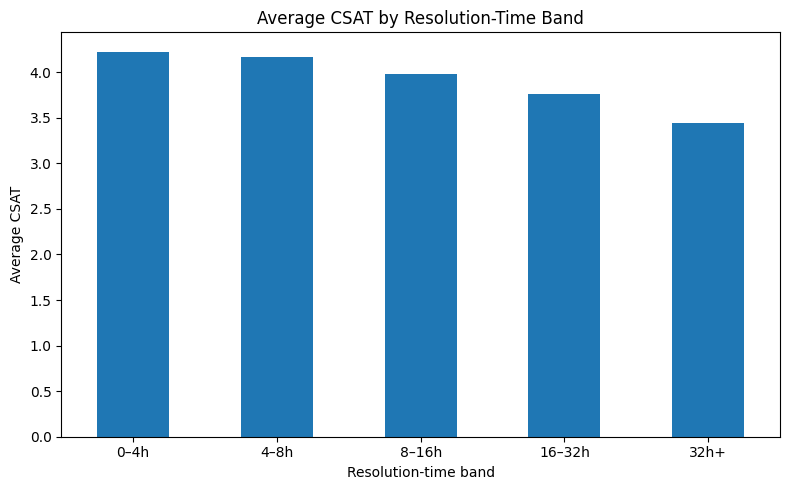

Correlation: resolution time vs CSAT = -0.268
Correlation: resolution time vs repeat contact = 0.043


In [10]:
csat_by_resolution = (
    df.groupby(pd.cut(
        df["resolution_time_hours"],
        bins=[0, 4, 8, 16, 32, np.inf],
        labels=["0–4h", "4–8h", "8–16h", "16–32h", "32h+"]
    ))["csat_score"].mean()
)

plt.figure(figsize=(8, 5))
csat_by_resolution.plot(kind="bar")
plt.title("Average CSAT by Resolution-Time Band")
plt.xlabel("Resolution-time band")
plt.ylabel("Average CSAT")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

corr_resolution_csat = df["resolution_time_hours"].corr(df["csat_score"])
corr_resolution_repeat = df["resolution_time_hours"].corr(df["repeat_contact"].astype(int))

print(f"Correlation: resolution time vs CSAT = {corr_resolution_csat:.3f}")
print(f"Correlation: resolution time vs repeat contact = {corr_resolution_repeat:.3f}")


## 10. Repeat Contact and Reopen Analysis

In [11]:
repeat_reopen = pd.DataFrame({
    "group": ["No repeat contact", "Repeat contact", "Not reopened", "Reopened"],
    "avg_csat": [
        df.loc[~df["repeat_contact"], "csat_score"].mean(),
        df.loc[df["repeat_contact"], "csat_score"].mean(),
        df.loc[~df["reopened"], "csat_score"].mean(),
        df.loc[df["reopened"], "csat_score"].mean(),
    ]
})

repeat_reopen


,group,avg_csat
0,No repeat contact,4.07
1,Repeat contact,3.76
2,Not reopened,4.07
3,Reopened,3.60


## 11. Customer Tier Analysis

In [12]:
tier_analysis = (
    df.groupby("customer_tier")
      .agg(
          tickets=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          escalation_rate=("escalated", "mean"),
          avg_csat=("csat_score", "mean"),
      )
      .reindex(["Standard", "Professional", "Enterprise"])
)

tier_analysis.style.format({
    "avg_resolution_hours": "{:.2f}",
    "escalation_rate": "{:.1%}",
    "avg_csat": "{:.2f}",
})


,tickets,avg_resolution_hours,escalation_rate,avg_csat
customer_tier,,,,
Standard,2727,10.41,14.3%,4.04
Professional,1650,10.23,13.2%,4.03
Enterprise,623,12.48,19.7%,4.04


## 12. Monthly Trend

Tracking volume and operational metrics over time helps distinguish one-off variation from persistent patterns.

In [13]:
monthly = (
    df.set_index("created_at")
      .resample("MS")
      .agg(
          tickets=("ticket_id", "count"),
          avg_resolution_hours=("resolution_time_hours", "mean"),
          sla_breach_rate=("sla_breached", "mean"),
          escalation_rate=("escalated", "mean"),
          avg_csat=("csat_score", "mean"),
      )
)

monthly


,tickets,avg_resolution_hours,sla_breach_rate,escalation_rate,avg_csat
created_at,,,,,
2026-01-01,872,10.63,0.21,0.14,4.07
2026-02-01,778,11.21,0.23,0.17,4.03
2026-03-01,867,10.50,0.21,0.15,4.03
2026-04-01,808,10.33,0.21,0.14,4.07
2026-05-01,836,10.13,0.20,0.13,4.04
2026-06-01,839,10.88,0.21,0.15,4.00


## 13. Initial Findings to Investigate

The following section is intentionally generated from the analysis rather than written as predetermined conclusions.

In [14]:
top_volume_category = category_analysis["tickets"].idxmax()
slowest_category = category_analysis["avg_resolution_hours"].idxmax()
highest_escalation_category = category_analysis["escalation_rate"].idxmax()
highest_sla_category = category_analysis["sla_breach_rate"].idxmax()

print(f"Highest ticket volume: {top_volume_category}")
print(f"Longest average resolution time: {slowest_category}")
print(f"Highest escalation rate: {highest_escalation_category}")
print(f"Highest SLA breach rate: {highest_sla_category}")
print(f"Resolution time vs CSAT correlation: {corr_resolution_csat:.3f}")
print(f"Resolution time vs repeat contact correlation: {corr_resolution_repeat:.3f}")


Highest ticket volume: Billing
Longest average resolution time: Security
Highest escalation rate: Security
Highest SLA breach rate: Integration
Resolution time vs CSAT correlation: -0.268
Resolution time vs repeat contact correlation: 0.043


## 14. AI Opportunity Screening

The data analysis does not automatically prove that AI is the correct solution. It helps identify where AI-assisted capabilities should be investigated further.

Potential MVP candidates will be assessed using:

- Ticket volume
- Operational impact
- Repetitiveness
- Availability of historical labels/context
- Risk level
- Human-review requirements
- Technical feasibility

### Candidate capabilities

| Capability | Evidence to validate |
|---|---|
| Ticket classification | High-volume categories and manual categorization |
| Ticket summarization | Long/unstructured conversations and review effort |
| Knowledge retrieval | Resolution-time and knowledge-search bottlenecks |
| Response drafting | Repetitive issue types and response patterns |
| Escalation summarization | Escalation volume and handoff/rework patterns |

These candidates will be prioritized only after the broader business and product analysis is complete.


## 15. BA/PM Interpretation

The purpose of this notebook is not simply to produce charts.

The analysis should connect:

**Data → Business Problem → Product Opportunity**

For each important finding, the next step is to ask:

1. What operational problem does the finding indicate?
2. Who experiences that problem?
3. How significant is the problem?
4. Can the problem be addressed through process change, product design, automation, AI, or a combination?
5. What evidence is needed before prioritizing the solution?

The next project phase will translate validated findings into **business requirements, functional requirements, user stories, and acceptance criteria**.
